## 1. Setup and Load Preprocessed Data
Loading all artifacts saved from the preprocessing stage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             classification_report, confusion_matrix,
                             roc_curve)

# Load preprocessed data
X_train = pd.read_csv('churnsight_artifacts/X_train.csv')
X_test = pd.read_csv('churnsight_artifacts/X_test.csv')
y_train = pd.read_csv('churnsight_artifacts/y_train.csv').squeeze()
y_test = pd.read_csv('churnsight_artifacts/y_test.csv').squeeze()

# Load artifacts
scaler = joblib.load('churnsight_artifacts/scaler.pkl')
class_weights = joblib.load('churnsight_artifacts/class_weights.pkl')
feature_cols = joblib.load('churnsight_artifacts/feature_cols.pkl')

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"\nClass weights: {class_weights}")
print(f"\nFeatures loaded: {len(feature_cols)}")

X_train: (5634, 44)
X_test:  (1409, 44)
y_train: (5634,)
y_test:  (1409,)

Class weights: {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}

Features loaded: 44


## 2. Model Building
Training three models: Logistic Regression, Random Forest, and XGBoost.
Each model uses class weights to handle the 73.5%/26.5% class imbalance.

### 2.1 Logistic Regression
Baseline linear model. Simple, interpretable, fast to train.

In [2]:
lr_model = LogisticRegression(
    class_weight=class_weights,
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(f"  Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"  F1 Score:  {f1_score(y_test, lr_pred):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, lr_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_pred, target_names=['Not Churned', 'Churned']))

Logistic Regression Results:
  Accuracy:  0.9510
  F1 Score:  0.9112
  AUC-ROC:   0.9919

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.98      0.95      0.97      1035
     Churned       0.88      0.95      0.91       374

    accuracy                           0.95      1409
   macro avg       0.93      0.95      0.94      1409
weighted avg       0.95      0.95      0.95      1409



### 2.2 Random Forest
Ensemble of decision trees. Handles non-linear relationships and feature interactions well.

In [3]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(f"  Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"  F1 Score:  {f1_score(y_test, rf_pred):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, rf_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_pred, target_names=['Not Churned', 'Churned']))

Random Forest Results:
  Accuracy:  0.9581
  F1 Score:  0.9175
  AUC-ROC:   0.9864

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.96      0.99      0.97      1035
     Churned       0.96      0.88      0.92       374

    accuracy                           0.96      1409
   macro avg       0.96      0.93      0.94      1409
weighted avg       0.96      0.96      0.96      1409



### 2.3 XGBoost
Gradient boosting model. Typically the strongest performer on tabular data.

In [4]:
# Calculate scale_pos_weight for XGBoost (alternative to class_weight)
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results:")
print(f"  Accuracy:  {accuracy_score(y_test, xgb_pred):.4f}")
print(f"  F1 Score:  {f1_score(y_test, xgb_pred):.4f}")
print(f"  AUC-ROC:   {roc_auc_score(y_test, xgb_prob):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_pred, target_names=['Not Churned', 'Churned']))

XGBoost Results:
  Accuracy:  0.9581
  F1 Score:  0.9204
  AUC-ROC:   0.9906

Classification Report:
              precision    recall  f1-score   support

 Not Churned       0.97      0.97      0.97      1035
     Churned       0.93      0.91      0.92       374

    accuracy                           0.96      1409
   macro avg       0.95      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



## 3. Model Comparison
Comparing all three models side by side to select the best performer.

Model Comparison:
                     Accuracy  F1 Score  AUC-ROC  Churned Recall
Model                                                           
Logistic Regression    0.9510    0.9112   0.9919          0.9465
Random Forest          0.9581    0.9175   0.9864          0.8770
XGBoost                0.9581    0.9204   0.9906          0.9118


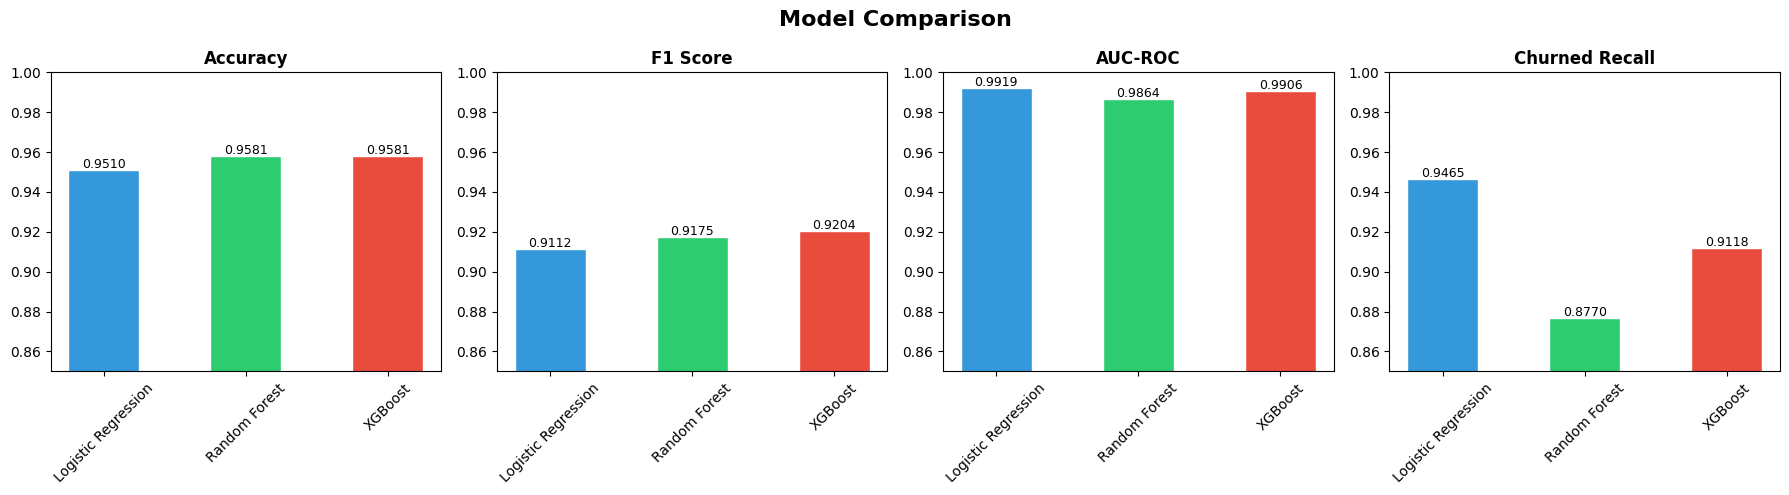

In [5]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ],
    'Churned Recall': [
        classification_report(y_test, lr_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, rf_pred, output_dict=True)['1']['recall'],
        classification_report(y_test, xgb_pred, output_dict=True)['1']['recall']
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
print("Model Comparison:")
print(results_df.round(4).to_string())

# Plot comparison
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['Accuracy', 'F1 Score', 'AUC-ROC', 'Churned Recall']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results_df.index, results_df[metric],
                       color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylim(0.85, 1.0)
    axes[i].tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.001,
                     f'{val:.4f}', ha='center', fontsize=9)

plt.suptitle('Model Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## 4. Model Selection
**Selected Model: XGBoost**

| Model | Accuracy | F1 Score | AUC-ROC | Churned Recall |
|---|---|---|---|---|
| Logistic Regression | 0.9510 | 0.9112 | 0.9919 | 0.9465 |
| Random Forest | 0.9581 | 0.9175 | 0.9864 | 0.8770 |
| **XGBoost** | **0.9581** | **0.9204** | **0.9906** | **0.9118** |

XGBoost selected for its best F1 Score, strong AUC-ROC, and native SHAP compatibility.

## 5. Final Model Evaluation
Deep evaluation of the selected XGBoost model using confusion matrix and ROC curve.

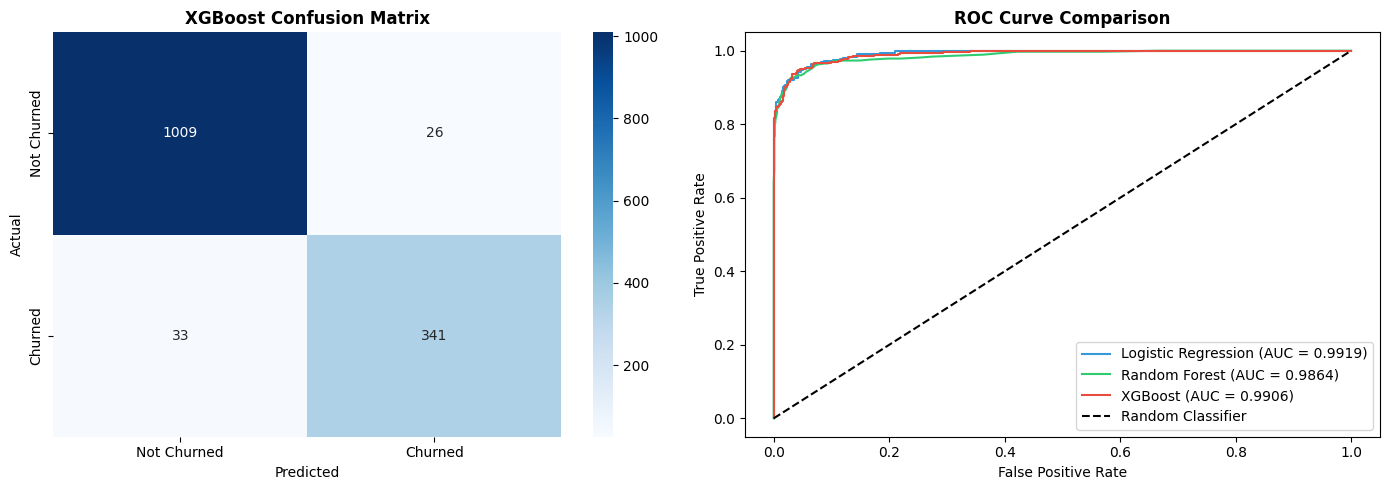

Confusion Matrix Breakdown:
  True Negatives  (correctly predicted not churned): 1009
  False Positives (predicted churned but did not):   26
  False Negatives (missed actual churners):          33
  True Positives  (correctly predicted churned):     341

  Churners correctly caught: 341/374 (91.2%)
  False alarms: 26/1035 (2.5%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'],
            ax=axes[0])
axes[0].set_title('XGBoost Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve for all three models
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

axes[1].plot(fpr_lr, tpr_lr, 
             label=f'Logistic Regression (AUC = 0.9919)', color='#3498db')
axes[1].plot(fpr_rf, tpr_rf, 
             label=f'Random Forest (AUC = 0.9864)', color='#2ecc71')
axes[1].plot(fpr_xgb, tpr_xgb, 
             label=f'XGBoost (AUC = 0.9906)', color='#e74c3c')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('final_evaluation.png', dpi=150)
plt.show()

# Print confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
print(f"Confusion Matrix Breakdown:")
print(f"  True Negatives  (correctly predicted not churned): {tn}")
print(f"  False Positives (predicted churned but did not):   {fp}")
print(f"  False Negatives (missed actual churners):          {fn}")
print(f"  True Positives  (correctly predicted churned):     {tp}")
print(f"\n  Churners correctly caught: {tp}/{tp+fn} ({tp/(tp+fn)*100:.1f}%)")
print(f"  False alarms: {fp}/{tn+fp} ({fp/(tn+fp)*100:.1f}%)")

> **Final Evaluation Summary:**
> - XGBoost correctly identified 341 out of 374 churners (91.2% recall)
> - Only 33 actual churners were missed (false negatives)
> - False alarm rate is just 2.5% meaning retention efforts are well targeted
> - All three ROC curves hug the top-left corner confirming strong discrimination across all models

## 6. Save Final Model

In [7]:
import os

# Save the final selected model
joblib.dump(xgb_model, 'churnsight_artifacts/xgb_model.pkl')

# Save all three models for reference
joblib.dump(lr_model, 'churnsight_artifacts/lr_model.pkl')
joblib.dump(rf_model, 'churnsight_artifacts/rf_model.pkl')

# Confirm saved
print("Models saved:")
for f in os.listdir('churnsight_artifacts'):
    size = os.path.getsize(f'churnsight_artifacts/{f}')
    print(f"  {f} ({size:,} bytes)")

Models saved:
  class_weights.pkl (144 bytes)
  feature_cols.pkl (876 bytes)
  lr_model.pkl (2,415 bytes)
  rf_model.pkl (7,260,345 bytes)
  scaler.pkl (1,415 bytes)
  xgb_model.pkl (210,707 bytes)
  X_test.csv (426,474 bytes)
  X_train.csv (1,702,729 bytes)
  y_test.csv (4,241 bytes)
  y_train.csv (16,916 bytes)
